# Faza 5 — baseline fine-tuning srpskog LipNet-a


## Goal

Fine-tune-uj preneti VIPL model na speaker-disjoint AI-SPEAK splitu. Prve tri
epohe uče samo novi srpski head, zatim se odmrzava ceo model. Najbolji checkpoint
bira se isključivo strogo manjim validation WER-om; test govornici se evaluiraju
tek nakon izbora modela.


## Setup

Izaberi **Runtime → Change runtime type → T4 GPU**. Notebook čuva `latest.pt`,
`best.pt`, istoriju i rezultate u `MyDrive/LipNet/phase5_length_aware_v2`, pa bezbedno nastavlja
rad posle prekida Colab sesije.

Folder ima novu oznaku zato što stari checkpoint-i nisu length-aware i ne smeju
se nastaviti niti porediti kao da koriste isti trening protokol.

Početni limit od 30 epoha produžen je na 45 jer je 30. epoha dala novi najbolji
validation WER. Pri nastavku je dozvoljeno samo povećanje `max_epochs`; svi ostali
hiperparametri moraju ostati identični checkpoint-u.


In [36]:
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'editdistance>=0.8.1', 'opencv-python-headless>=4.10',
     'nbformat>=5.10.4', 'pytest>=8.4'],
    check=True,
)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'editdistance>=0.8.1', 'opencv-python-headless>=4.10', 'nbformat>=5.10.4', 'pytest>=8.4'], returncode=0)

In [37]:
import importlib
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = 'https://github.com/nikolabakic/Vizuelno-prepoznavanje-govora-na-osnovu-pokreta-usana-pomo-u-LipNet-modela.git'
REPO = Path('/content/lipnet-serbian')
if not (REPO / 'lipnet').exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO)], check=True)
else:
    subprocess.run(['git', '-C', str(REPO), 'pull', '--ff-only'], check=True)
os.chdir(REPO)

# A git pull updates source files, but an active Colab kernel can still hold
# old lipnet modules in sys.modules.  Clear only this project's modules so
# all later imports use one coherent checkout.
stale_modules = [
    name for name in sys.modules
    if name == 'lipnet' or name.startswith('lipnet.')
]
for name in stale_modules:
    del sys.modules[name]
repo_path = str(REPO)
sys.path[:] = [entry for entry in sys.path if entry != repo_path]
sys.path.insert(0, repo_path)
importlib.invalidate_caches()

print('Repo:', REPO)
print('Commit:', subprocess.check_output(['git', 'rev-parse', 'HEAD'], text=True).strip())
if stale_modules:
    print('Osveženi Python moduli:', ', '.join(sorted(stale_modules)))


Repo: /content/lipnet-serbian
Commit: c4ef9556591719ebabcbe6460baf2f2d9a516fb7
Osveženi Python moduli: lipnet, lipnet.cvtransforms, lipnet.dataset, lipnet.model, lipnet.train


In [38]:
import inspect
import json
import random
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import torch

from lipnet.model import LipNet
from lipnet.train import FineTuneConfig

forward_parameters = inspect.signature(LipNet.forward).parameters
assert 'lengths' in forward_parameters, (
    'Učitana LipNet klasa nije length-aware. Ponovo pokreni Setup ćelije; '
    f'model={inspect.getfile(LipNet)}, signature={inspect.signature(LipNet.forward)}'
)
assert torch.cuda.is_available(), 'Uključi T4 GPU u Colab Runtime postavkama.'
DEVICE = torch.device('cuda')
CONFIG = FineTuneConfig(
    max_epochs=45,
    warmup_epochs=3,
    early_stopping_patience=5,
    batch_size=2,
    backbone_lr=2e-5,
    head_lr=1e-4,
    num_workers=2,
    random_seed=0,
)
random.seed(CONFIG.random_seed)
np.random.seed(CONFIG.random_seed)
torch.manual_seed(CONFIG.random_seed)
torch.cuda.manual_seed_all(CONFIG.random_seed)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
print('LipNet:', inspect.getfile(LipNet), inspect.signature(LipNet.forward))
print('GPU:', torch.cuda.get_device_name(0))
print('Konfiguracija:', json.dumps(asdict(CONFIG), indent=2))


LipNet: /content/lipnet-serbian/lipnet/model.py (self, x: 'torch.Tensor', lengths: 'torch.Tensor | None' = None) -> 'torch.Tensor'
GPU: NVIDIA L4
Konfiguracija: {
  "max_epochs": 45,
  "warmup_epochs": 3,
  "early_stopping_patience": 5,
  "batch_size": 2,
  "backbone_lr": 2e-05,
  "head_lr": 0.0001,
  "num_workers": 2,
  "random_seed": 0
}


In [39]:
from google.colab import drive

drive.mount('/content/drive')
DRIVE_ROOT = Path('/content/drive/MyDrive/LipNet')
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)
print('Drive izlaz:', DRIVE_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive izlaz: /content/drive/MyDrive/LipNet


In [40]:
TRAINING_PROTOCOL = 'length-aware-bigru-corpus-metrics-v2'
PHASE5_DIR = DRIVE_ROOT / 'phase5_length_aware_v2'
PHASE5_DIR.mkdir(parents=True, exist_ok=True)
LATEST_CHECKPOINT = PHASE5_DIR / 'latest.pt'
BEST_CHECKPOINT = PHASE5_DIR / 'best.pt'
HISTORY_PATH = PHASE5_DIR / 'history.json'
RESULTS_PATH = PHASE5_DIR / 'results.json'
CURVES_PATH = PHASE5_DIR / 'training_curves.png'
print('Phase 5 izlaz:', PHASE5_DIR)


Phase 5 izlaz: /content/drive/MyDrive/LipNet/phase5_length_aware_v2


### 0. Pokreni CPU kompatibilnosne testove


In [41]:
subprocess.run(
    [sys.executable, '-m', 'pytest', '-q',
     'tests/test_vipl_phases.py', 'tests/test_phase5.py'],
    check=True,
)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', '-q', 'tests/test_vipl_phases.py', 'tests/test_phase5.py'], returncode=0)

## Steps

### 1. Raspakuj mouth frejmove i ALIGN anotacije na lokalni disk


In [42]:
import zipfile

MOUTH_ARCHIVE = DRIVE_ROOT / 'ai_speak_lip.zip'
SOURCE_ARCHIVE = Path('/content/drive/MyDrive/processed.zip')  # promeni po potrebi
MOUTH_ROOT = Path('/content/ai_speak_lip')
ALIGN_EXTRACT = Path('/content/ai_speak_align')
assert MOUTH_ARCHIVE.exists(), MOUTH_ARCHIVE
assert SOURCE_ARCHIVE.exists(), SOURCE_ARCHIVE

if not next(MOUTH_ROOT.glob('spk*/video/video_a/*'), None):
    MOUTH_ROOT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(MOUTH_ARCHIVE) as archive:
        archive.extractall(MOUTH_ROOT)
if not next(ALIGN_EXTRACT.rglob('spk*/alignment/*.align'), None):
    ALIGN_EXTRACT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(SOURCE_ARCHIVE) as archive:
        members = [
            member for member in archive.infolist()
            if '/alignment/' in f'/{member.filename}'
            and member.filename.endswith('.align')
        ]
        archive.extractall(ALIGN_EXTRACT, members=members)
first_alignment = next(ALIGN_EXTRACT.rglob('spk*/alignment/*.align'))
CORPUS_ROOT = first_alignment.parents[2]
print('Mouth root:', MOUTH_ROOT)
print('Annotation root:', CORPUS_ROOT)


Mouth root: /content/ai_speak_lip
Annotation root: /content/ai_speak_align/processed


### 2. Formiraj splitove i runtime CTC filter bez manifesta


In [43]:
from torch.utils.data import DataLoader, Subset

from data.splits import (
    SPLITS, TEST_SPEAKERS, TRAIN_SPEAKERS, VALIDATION_SPEAKERS,
)
from lipnet.dataset import SerbianDataset, variable_length_collate
from lipnet.train import scan_ctc_compatibility

raw_datasets = {
    'train': SerbianDataset(MOUTH_ROOT, CORPUS_ROOT, TRAIN_SPEAKERS, phase='train'),
    'validation': SerbianDataset(
        MOUTH_ROOT, CORPUS_ROOT, VALIDATION_SPEAKERS, phase='validation'
    ),
    'test': SerbianDataset(MOUTH_ROOT, CORPUS_ROOT, TEST_SPEAKERS, phase='test'),
}
for name, dataset in raw_datasets.items():
    expected = {
        (speaker, path.stem)
        for speaker in SPLITS[name]
        for path in (CORPUS_ROOT / speaker / 'alignment').glob('*.align')
    }
    discovered = {(speaker, sample_id) for _, speaker, sample_id in dataset.data}
    assert discovered == expected, (
        f'{name}: očekivano={len(expected)} pronađeno={len(discovered)}'
    )
ctc_reports = {
    name: scan_ctc_compatibility(dataset)
    for name, dataset in raw_datasets.items()
}
datasets = {
    name: Subset(raw_datasets[name], report.valid_indices)
    for name, report in ctc_reports.items()
}
for name, report in ctc_reports.items():
    print(
        f'{name:10s}: valid={report.valid_count}, '
        f'CTC-odbačeno={report.invalid_count}'
    )

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_loader(name, *, epoch=0, shuffle=False):
    generator = torch.Generator()
    generator.manual_seed(CONFIG.random_seed + epoch)
    return DataLoader(
        datasets[name],
        batch_size=CONFIG.batch_size,
        shuffle=shuffle,
        num_workers=CONFIG.num_workers,
        collate_fn=variable_length_collate,
        pin_memory=True,
        worker_init_fn=seed_worker,
        generator=generator,
        persistent_workers=False,
    )


train     : valid=2877, CTC-odbačeno=0
validation: valid=540, CTC-odbačeno=0
test      : valid=540, CTC-odbačeno=0


### 3. Učitaj transfer ili automatski nastavi `latest.pt`


In [44]:
from urllib.request import urlretrieve

from lipnet.dataset import SERBIAN_LETTERS
from lipnet.model import LipNet
from lipnet.train import (
    build_finetune_optimizer, greedy_decode, load_training_checkpoint,
    load_vipl_transfer, set_backbone_trainable, validate_resume_config,
)

UPSTREAM_SHA = '40209e09c49553c00c25c7d41faa3706aea3c625'
VIPL_CHECKPOINT = Path('/content') / 'LipNet_unseen_loss_0.44562849402427673_wer_0.1332580699113564_cer_0.06796452465503355.pt'
VIPL_CHECKPOINT_URL = (
    'https://raw.githubusercontent.com/VIPL-Audio-Visual-Speech-Understanding/'
    f'LipNet-PyTorch/{UPSTREAM_SHA}/pretrain/LipNet_unseen_loss_0.44562849402427673_wer_0.1332580699113564_cer_0.06796452465503355.pt'
)
if not VIPL_CHECKPOINT.exists():
    urlretrieve(VIPL_CHECKPOINT_URL, VIPL_CHECKPOINT)

NUM_CLASSES = 1 + len(SERBIAN_LETTERS)
assert NUM_CLASSES == 29
model = LipNet(num_classes=NUM_CLASSES).to(DEVICE)
optimizer = build_finetune_optimizer(
    model, backbone_lr=CONFIG.backbone_lr, head_lr=CONFIG.head_lr
)

if LATEST_CHECKPOINT.exists():
    state = load_training_checkpoint(LATEST_CHECKPOINT, model, optimizer)
    validate_resume_config(state.config, CONFIG)
    start_epoch = state.next_epoch
    best_val_wer = state.best_val_wer
    best_epoch = state.best_epoch
    epochs_without_improvement = state.epochs_without_improvement
    history = list(state.history)
    audit = None
    print('Nastavljam od epohe', start_epoch + 1)
else:
    audit = load_vipl_transfer(model, VIPL_CHECKPOINT)
    assert set(audit.skipped_shape) == {'FC.weight', 'FC.bias'}
    assert not audit.missing_in_checkpoint and not audit.unexpected_in_checkpoint
    start_epoch = 0
    best_val_wer = float('inf')
    best_epoch = -1
    epochs_without_improvement = 0
    history = []
    print('Novi trening:', audit.summary())

set_backbone_trainable(model, start_epoch >= CONFIG.warmup_epochs)


Nastavljam od epohe 31


('conv1.weight',
 'conv1.bias',
 'conv2.weight',
 'conv2.bias',
 'conv3.weight',
 'conv3.bias',
 'gru1.weight_ih_l0',
 'gru1.weight_hh_l0',
 'gru1.bias_ih_l0',
 'gru1.bias_hh_l0',
 'gru1.weight_ih_l0_reverse',
 'gru1.weight_hh_l0_reverse',
 'gru1.bias_ih_l0_reverse',
 'gru1.bias_hh_l0_reverse',
 'gru2.weight_ih_l0',
 'gru2.weight_hh_l0',
 'gru2.bias_ih_l0',
 'gru2.bias_hh_l0',
 'gru2.weight_ih_l0_reverse',
 'gru2.weight_hh_l0_reverse',
 'gru2.bias_ih_l0_reverse',
 'gru2.bias_hh_l0_reverse',
 'FC.weight',
 'FC.bias')

### 4. Treniraj, validiraj i čuvaj latest/best checkpoint


In [45]:
from lipnet.train import (
    run_epoch, save_training_checkpoint, validation_wer_improved,
)

checkpoint_metadata = {
    'phase': 5,
    'training_protocol': TRAINING_PROTOCOL,
    'upstream_commit': UPSTREAM_SHA,
    'num_classes': NUM_CLASSES,
    'speakers': {name: list(value) for name, value in SPLITS.items()},
    'ctc_filter': {
        name: {'valid': report.valid_count, 'invalid': report.invalid_count}
        for name, report in ctc_reports.items()
    },
    'environment': {
        'torch_version': torch.__version__,
        'cuda_version': torch.version.cuda,
        'gpu': torch.cuda.get_device_name(0),
    },
}

assert 'lengths' in inspect.signature(model.forward).parameters, (
    'Model u memoriji nije length-aware; pokreni notebook ponovo od Setup sekcije.'
)
for epoch in range(start_epoch, CONFIG.max_epochs):
    backbone_trainable = epoch >= CONFIG.warmup_epochs
    set_backbone_trainable(model, backbone_trainable)
    train_result = run_epoch(
        model,
        make_loader('train', epoch=epoch, shuffle=True),
        DEVICE,
        optimizer,
    )
    validation_result = run_epoch(
        model, make_loader('validation'), DEVICE
    )
    improved = validation_wer_improved(validation_result.wer, best_val_wer)
    if improved:
        best_val_wer = validation_result.wer
        best_epoch = epoch

    if epoch < CONFIG.warmup_epochs:
        epochs_without_improvement = 0
    elif improved:
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    record = {
        'epoch': epoch,
        'stage': 'full' if backbone_trainable else 'head_only',
        'train': train_result.metrics(),
        'validation': validation_result.metrics(),
    }
    history.append(record)
    checkpoint_arguments = dict(
        model=model,
        optimizer=optimizer,
        epoch=epoch,
        best_val_wer=best_val_wer,
        best_epoch=best_epoch,
        epochs_without_improvement=epochs_without_improvement,
        history=history,
        config=CONFIG,
        metadata=checkpoint_metadata,
    )
    if improved:
        save_training_checkpoint(BEST_CHECKPOINT, **checkpoint_arguments)
    save_training_checkpoint(LATEST_CHECKPOINT, **checkpoint_arguments)
    HISTORY_PATH.write_text(
        json.dumps(history, indent=2, ensure_ascii=False) + '\n',
        encoding='utf-8',
    )

    print(
        f'Epoha {epoch + 1:02d}/{CONFIG.max_epochs} '
        f'[{record["stage"]}] '
        f'train loss={train_result.loss:.4f} WER={train_result.wer:.4f} | '
        f'val loss={validation_result.loss:.4f} '
        f'WER={validation_result.wer:.4f} CER={validation_result.cer:.4f} '
        f'exact={validation_result.sentence_exact_match:.4f}'
        + ('  *BEST*' if improved else '')
    )
    if (
        epoch >= CONFIG.warmup_epochs
        and epochs_without_improvement >= CONFIG.early_stopping_patience
    ):
        print('Early stopping: validation WER se nije poboljšao.')
        break

assert BEST_CHECKPOINT.exists(), 'Nije sačuvan najbolji checkpoint.'
print('Najbolja epoha:', best_epoch + 1, 'validation WER:', best_val_wer)


Epoha 31/45 [full] train loss=0.5035 WER=0.4923 | val loss=0.7257 WER=0.5287 CER=0.2339 exact=0.0000  *BEST*
Epoha 32/45 [full] train loss=0.4965 WER=0.4891 | val loss=0.7160 WER=0.5191 CER=0.2314 exact=0.0000  *BEST*
Epoha 33/45 [full] train loss=0.4823 WER=0.4757 | val loss=0.7576 WER=0.5275 CER=0.2368 exact=0.0000
Epoha 34/45 [full] train loss=0.4867 WER=0.4815 | val loss=0.7614 WER=0.5299 CER=0.2361 exact=0.0000
Epoha 35/45 [full] train loss=0.4657 WER=0.4684 | val loss=0.7707 WER=0.5204 CER=0.2346 exact=0.0000
Epoha 36/45 [full] train loss=0.4669 WER=0.4639 | val loss=0.7327 WER=0.5133 CER=0.2287 exact=0.0000  *BEST*
Epoha 37/45 [full] train loss=0.4607 WER=0.4643 | val loss=0.7827 WER=0.5160 CER=0.2322 exact=0.0000
Epoha 38/45 [full] train loss=0.4513 WER=0.4596 | val loss=0.7238 WER=0.5083 CER=0.2240 exact=0.0000  *BEST*
Epoha 39/45 [full] train loss=0.4509 WER=0.4573 | val loss=0.7583 WER=0.5160 CER=0.2313 exact=0.0000
Epoha 40/45 [full] train loss=0.4373 WER=0.4482 | val loss=

### 5. Prikaži i sačuvaj krive treniranja


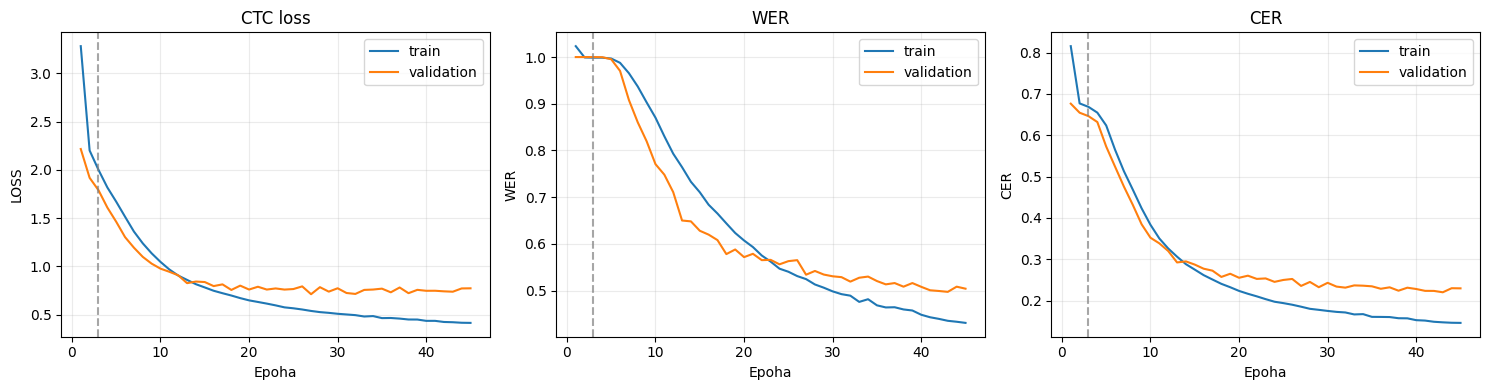

In [46]:
epochs = [item['epoch'] + 1 for item in history]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, metric, title in zip(
    axes, ('loss', 'wer', 'cer'), ('CTC loss', 'WER', 'CER')
):
    axis.plot(epochs, [item['train'][metric] for item in history], label='train')
    axis.plot(
        epochs,
        [item['validation'][metric] for item in history],
        label='validation',
    )
    axis.axvline(CONFIG.warmup_epochs, color='gray', linestyle='--', alpha=0.7)
    axis.set(title=title, xlabel='Epoha', ylabel=metric.upper())
    axis.grid(alpha=0.25)
    axis.legend()
plt.tight_layout()
fig.savefig(CURVES_PATH, dpi=160, bbox_inches='tight')
plt.show()


## Checks

### 6. Učitaj `best.pt` i evaluiraj neviđene test govornike jednom


In [47]:
import hashlib

from lipnet.train import load_training_checkpoint

best_state = load_training_checkpoint(
    BEST_CHECKPOINT, model, optimizer, restore_rng=False
)
assert best_state.best_epoch == best_state.next_epoch - 1
best_validation = next(
    item['validation']
    for item in best_state.history
    if item['epoch'] == best_state.best_epoch
)
checkpoint_hasher = hashlib.sha256()
with BEST_CHECKPOINT.open('rb') as checkpoint_file:
    for chunk in iter(lambda: checkpoint_file.read(1024 * 1024), b''):
        checkpoint_hasher.update(chunk)
best_checkpoint_sha256 = checkpoint_hasher.hexdigest()
FORCE_TEST_REEVALUATION = False
previous_results = None
if RESULTS_PATH.exists():
    previous_results = json.loads(RESULTS_PATH.read_text(encoding='utf-8'))

if (
    previous_results is not None
    and previous_results.get('metrics_definition') == 'corpus-edit-distance-v1'
    and previous_results.get('best_epoch') == best_state.best_epoch
    and previous_results.get('best_checkpoint_sha256') == best_checkpoint_sha256
    and not FORCE_TEST_REEVALUATION
):
    results = previous_results
    print('Koristim već sačuvanu test evaluaciju za isti best checkpoint.')
else:
    test_result = run_epoch(model, make_loader('test'), DEVICE)
    qualitative = [
        {'reference': reference, 'prediction': prediction}
        for reference, prediction in list(
            zip(test_result.references, test_result.predictions)
        )[:10]
    ]
    results = {
        'phase': 5,
        'training_protocol': TRAINING_PROTOCOL,
        'metrics_definition': 'corpus-edit-distance-v1',
        'upstream_commit': UPSTREAM_SHA,
        'config': asdict(CONFIG),
        'best_epoch': best_state.best_epoch,
        'best_validation_wer': best_state.best_val_wer,
        'best_checkpoint_sha256': best_checkpoint_sha256,
        'validation': best_validation,
        'test': test_result.metrics(),
        'test_samples': test_result.samples,
        'qualitative': qualitative,
        'ctc_filter': checkpoint_metadata['ctc_filter'],
        'environment': checkpoint_metadata['environment'],
    }
    RESULTS_PATH.write_text(
        json.dumps(results, indent=2, ensure_ascii=False) + '\n',
        encoding='utf-8',
    )

print(json.dumps({
    'best_epoch': results['best_epoch'] + 1,
    'validation': results['validation'],
    'test': results['test'],
    'test_samples': results['test_samples'],
}, indent=2, ensure_ascii=False))
for item in results['qualitative']:
    print('REF :', item['reference'])
    print('PRED:', item['prediction'])
    print()


{
  "best_epoch": 43,
  "validation": {
    "loss": 0.7389641046524048,
    "wer": 0.49722222222222223,
    "cer": 0.2201864147088866,
    "sentence_exact_match": 0.0
  },
  "test": {
    "loss": 0.56529464473327,
    "wer": 0.4524691358024691,
    "cer": 0.18238672622846203,
    "sentence_exact_match": 0.0
  },
  "test_samples": 540
}
REF : obriši d levo i nedelja dva
PRED: obraši b levo nedeltak dva

REF : dalje z dole i četvrtak devet
PRED: kaje r gole četvrtak etrt

REF : kraj r desno j sreda devet
PRED: kraj h desno nedelja šest

REF : dalje z levo r ponedeljak osam
PRED: daje b levo ponedeljak šest

REF : pošalji lj levo g četvrtak četiri
PRED: pošalji i levo četvrtak četiri

REF : odustani k desno m subota dva
PRED: odustani d levo subota dva

REF : odustani h dole a ponedeljak četiri
PRED: odustani š gore ponedeljak četiri

REF : početak f napred o subota sedam
PRED: počštaji m levo subota sedan

REF : kraj e levo b sreda jedan
PRED: kraj h levo sreda osam

REF : potvrdi d desn

### 7. Potvrdi checkpoint round-trip i inference ugovor


In [48]:
reloaded_model = LipNet(num_classes=NUM_CLASSES).to(DEVICE)
reloaded_optimizer = build_finetune_optimizer(
    reloaded_model,
    backbone_lr=CONFIG.backbone_lr,
    head_lr=CONFIG.head_lr,
)
reloaded_state = load_training_checkpoint(
    BEST_CHECKPOINT, reloaded_model, reloaded_optimizer, restore_rng=False
)
inference_batch = next(iter(make_loader('test')))
reloaded_model.eval()
with torch.no_grad():
    inference_logits = reloaded_model(
        inference_batch['vid'].to(DEVICE),
        lengths=inference_batch['vid_len'],
    )
inference_text = greedy_decode(
    inference_logits, output_lengths=inference_batch['vid_len']
)
assert len(inference_text) == inference_batch['vid'].shape[0]
assert reloaded_state.best_epoch == results['best_epoch']
print('PASS: best checkpoint se ponovo učitava i daje inference:', inference_text)


PASS: best checkpoint se ponovo učitava i daje inference: ['obraši b levo nedeltak dva', 'kaje r gole četvrtak etrt']


## Next Steps

Faza 5 je završena kada postoje `best.pt`, `latest.pt`, istorija, krive i test
rezultat za neviđene govornike. Faza 6 mora koristiti isti `best.pt`, isti test
split i isti greedy dekoder; menja se samo ulazna rezolucija, blur ili crop jitter.
